In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2026-04-05 12:32:52.872361: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 12:32:52.925654: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 12:32:56.668527: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from hyperion_utils import *
from sklearn.decomposition import PCA

In [4]:
myTreatmentColumn = 'groupe'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'CPC12', 
                                                                         aTreatmentColumn = myTreatmentColumn,     
                                                                         aSkipTemp = False) 

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
def missingness_table(df, treatment_col, threshold=30.0, exclude_cols=None, use_fisher_if_small=True):
    """
    Create a missingness summary table for one dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Pre-imputation dataframe.
    treatment_col : str
        Name of binary treatment column (0/1).
    threshold : float
        Percent missing threshold to flag, default 30.
    exclude_cols : list or None
        Columns to exclude from the missingness table.
    use_fisher_if_small : bool
        Use Fisher's exact test when expected cell counts are small.

    Returns
    -------
    pd.DataFrame
    """
    if exclude_cols is None:
        exclude_cols = []

    cols = [c for c in df.columns if c not in exclude_cols and c != treatment_col]

    rows = []

    treat = df[treatment_col]

    for col in cols:
        miss = df[col].isna().astype(int)

        n_total = len(df)
        n_missing = miss.sum()
        pct_missing = 100 * n_missing / n_total

        miss_ttm = miss[treat == 1]
        miss_nottm = miss[treat == 0]

        n_ttm = (treat == 1).sum()
        n_nottm = (treat == 0).sum()

        pct_missing_ttm = 100 * miss_ttm.mean() if n_ttm > 0 else np.nan
        pct_missing_nottm = 100 * miss_nottm.mean() if n_nottm > 0 else np.nan

        # contingency table:
        # rows = treatment group
        # cols = missing / not missing
        table = np.array([
            [miss_nottm.sum(), (treat == 0).sum() - miss_nottm.sum()],
            [miss_ttm.sum(), (treat == 1).sum() - miss_ttm.sum()]
        ])

        # default p-value
        pval = np.nan
        test_used = None

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)

            if use_fisher_if_small and (expected < 5).any():
                _, pval = fisher_exact(table)
                test_used = "Fisher"
            else:
                pval = p_chi
                test_used = "Chi-square"
        except Exception:
            pval = np.nan
            test_used = "Failed"

        rows.append({
            "variable": col,
            "n_missing": int(n_missing),
            "pct_missing": pct_missing,
            "pct_missing_no_ttm": pct_missing_nottm,
            "pct_missing_ttm": pct_missing_ttm,
            "abs_diff_pct": abs(pct_missing_ttm - pct_missing_nottm),
            "p_value": pval,
            "test": test_used,
            "flag_gt_30pct": pct_missing > threshold
        })

    out = pd.DataFrame(rows).sort_values(
        ["flag_gt_30pct", "pct_missing"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out
miss_eicu = missingness_table(
    df=pd.concat([X_train, X_test]),
    treatment_col="groupe",
    exclude_cols=["patient_id"]
)
def missingness_summary_stats(miss_df):
    return {
        "n_variables": len(miss_df),
        "n_gt_30pct": int(miss_df["flag_gt_30pct"].sum()),
        "max_pct_missing": miss_df["pct_missing"].max(),
        "median_pct_missing": miss_df["pct_missing"].median(),
        "n_p_lt_005": int((miss_df["p_value"] < 0.05).sum())
    }
print("eICU:", missingness_summary_stats(miss_eicu))

eICU: {'n_variables': 157, 'n_gt_30pct': 50, 'max_pct_missing': np.float64(97.07401032702238), 'median_pct_missing': np.float64(4.475043029259897), 'n_p_lt_005': 3}


In [6]:
miss_eicu = miss_eicu.rename(columns={
    "variable": "Variable",
    "n_missing": "Missing, n",
    "pct_missing": "Missing, %",
    "pct_missing_no_ttm": "Missing in No-TTM Group, %",
    "pct_missing_ttm": "Missing in TTM Group, %",
    "abs_diff_pct": "Absolute Difference, %",
    "p_value": "P Value",
    "test": "Statistical Test"
}).drop(columns=["flag_gt_30pct"])

In [7]:
miss_eicu.to_csv('table.csv')

In [8]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [9]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    # myCovariates = getCovariatePreprocessor(['bin__' + myTreatmentColumn])
    # myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [10]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [11]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2026-04-05 12:33:02.654086: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [12]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9113 - loss: 0.3617 - roc_auc: 0.4924 - val_accuracy: 0.9200 - val_loss: 0.2687 - val_roc_auc: 0.6684
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9236 - loss: 0.2716 - roc_auc: 0.6287 - val_accuracy: 0.9200 - val_loss: 0.2479 - val_roc_auc: 0.7677
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9236 - loss: 0.2598 - roc_auc: 0.6810 - val_accuracy: 0.9200 - val_loss: 0.2324 - val_roc_auc: 0.8212
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9236 - loss: 0.2327 - roc_auc: 0.7652 - val_accuracy: 0.9200 - val_loss: 0.2244 - val_roc_auc: 0.8494
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9335 - loss: 0.2078 - roc_auc: 0.8362 - val_accuracy: 0.9200 - val_loss: 0.2173 - val_roc_auc: 0.8587
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9384 - loss: 0.1848 - roc_auc: 0.8865 - val_accuracy: 0.9200 - val_loss: 0.2127 - val_roc_auc: 0.8600
Epoch 7/15
13/

In [13]:
calib_table

NameError: name 'calib_table' is not defined

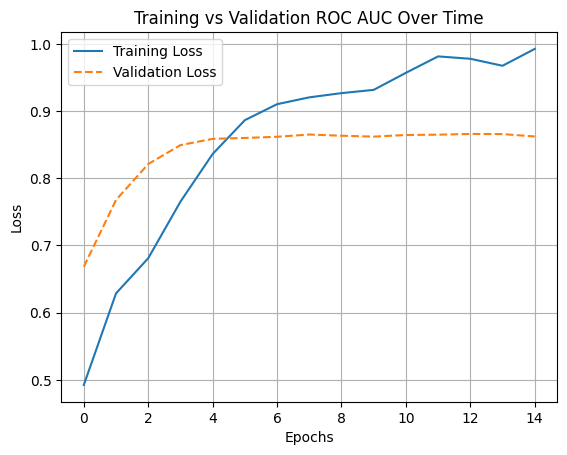

In [14]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


ROC AUC Score: 0.8616


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'HYPERION NN Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

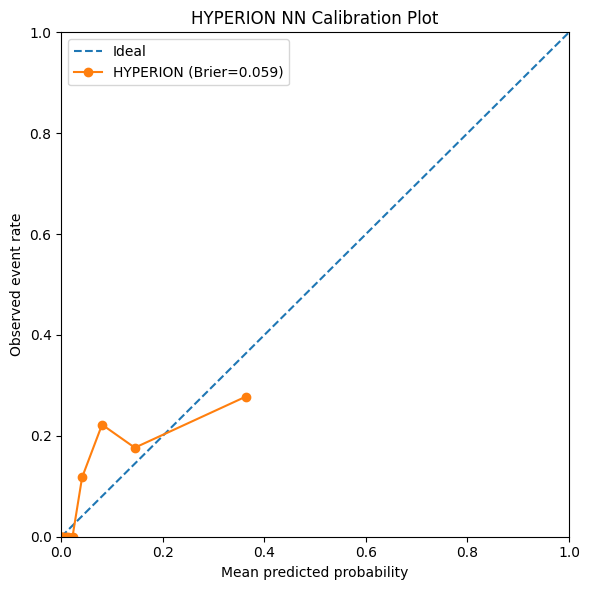

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, y_pred_probs),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"HYPERION":y_pred_probs}, y_test, "HYPERION NN Calibration Plot")

In [17]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,175,0.08,0.861579,0.059075,0.013774,0.891417


In [18]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/home/mbranda1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7669/7669 ━━━━━━━━━━━━━━━━━━━━ 5s 623us/step


 10%|█         | 1/10 [00:08<01:13,  8.18s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7669/7669 ━━━━━━━━━━━━━━━━━━━━ 5s 620us/step


 20%|██        | 2/10 [00:15<01:03,  7.92s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
7003/7669 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step

 20%|██        | 2/10 [00:21<01:26, 10.75s/it]


KeyboardInterrupt: 

In [14]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__groupe"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__groupe' is ranked #171 out of 222 in importance with mean(|SHAP|) = 0.0002


In [16]:
y_pred_probs.T[0, :]

array([1.13434039e-01, 2.78856052e-04, 1.68566387e-02, 8.65397800e-04,
       3.89784644e-03, 6.17709290e-03, 8.61611962e-02, 3.26378495e-02,
       1.25186592e-01, 2.88149059e-01, 9.29038739e-04, 1.19703659e-03,
       8.47152807e-03, 2.77577378e-02, 6.12306921e-03, 2.22417247e-03,
       1.84005557e-03, 1.36765768e-04, 4.25638855e-02, 3.52215581e-02,
       1.87280595e-01, 4.81105223e-02, 3.48059721e-02, 2.59975381e-02,
       1.35487484e-04, 2.58279052e-02, 4.76200774e-04, 4.80452925e-02,
       1.49062136e-03, 3.46969930e-03, 7.21949246e-03, 1.97706804e-01,
       1.13088991e-02, 4.45527345e-04, 6.44543990e-02, 1.30159169e-01,
       4.94116079e-03, 1.93661377e-02, 4.07735854e-02, 4.94533498e-03,
       4.21050191e-02, 7.04219332e-03, 5.47189964e-03, 1.10588409e-02,
       4.12089795e-01, 2.53549784e-01, 1.11381186e-03, 3.14481318e-01,
       8.63598194e-03, 4.28301375e-03, 1.02805470e-05, 2.28468068e-02,
       1.71750113e-02, 2.21768185e-03, 4.61331016e-04, 1.84003811e-03,
      

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Optimization terminated successfully.
         Current function value: 0.266554
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263996
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 2.076808932228545
p-value: 0.1495525406108744
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  406
Model:                          Logit   Df Residuals:                      403
Method:                           MLE   Df Model:                            2
Date:                Thu, 05 Jun 2025   Pseudo R-squ.:                 0.01194
Time:                        20:25:31   Log-Likelihood:                -108.22
converged:                       True   LL-Null:                       -109.53
Covariance Type:      

0.1495525406108744

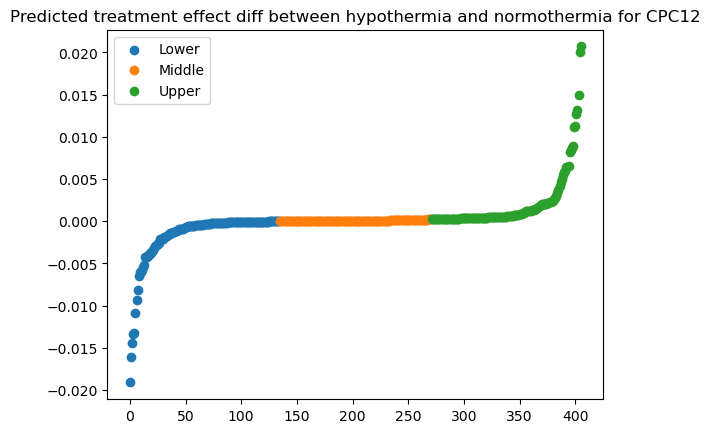

In [17]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Optimization terminated successfully.
         Current function value: 0.274583
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.274260
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.11278136073011069
p-value: 0.7369995467194708
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  175
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.01502
Time:                        17:39:34   Log-Likelihood:                -48.052
converged:                       True   LL-Null:                       -48.785
Covariance Type:        

0.7369995467194708

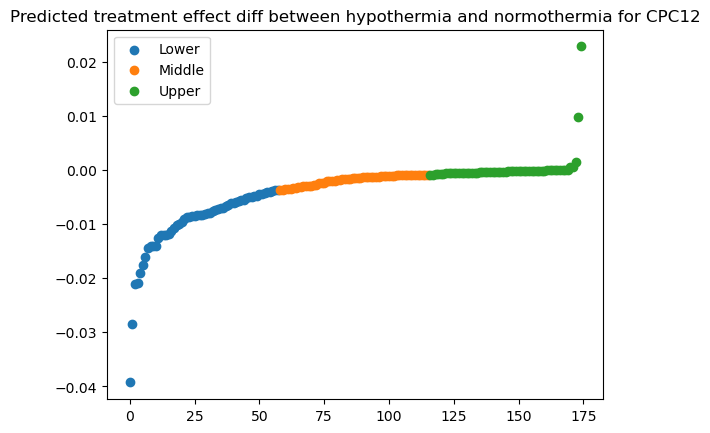

In [16]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined